In [4]:
## Dataset Reading ## Voting Ensemble
import pandas as pd
import numpy as np
df = pd.read_csv("processed_heart_disease_uci.csv")
df

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,0,0,1,0,0,0,0,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,1,0,0,0,0,0,1,0,1,0
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,0,0,0,0,0,1,0,0,1
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,0,1,0,1,0,0,0,1,0
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,127.0,333.0,1,154.0,0,0.0,0.0,1,0,0,0,0,1,1,0,1,0
916,62,1,130.0,139.0,0,140.0,0,0.5,0.0,0,0,0,1,0,1,1,0,1,0
917,55,1,122.0,223.0,1,100.0,0,0.0,0.0,1,0,0,0,0,1,1,0,0,0
918,58,1,130.0,385.0,1,140.0,0,0.5,0.0,0,0,0,0,0,0,1,0,1,0


In [5]:
from sklearn.model_selection import train_test_split
columns = df.columns
columns = columns.drop("target")
X = df[columns]
Y = df["target"]

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X , Y , test_size = 0.2 , random_state= 42)

In [7]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(min_samples_split = 10 , min_samples_leaf  = 6 , 
                            n_estimators = 75 , max_samples = 0.75 , random_state= 42 , max_depth = 8 , bootstrap = True, oob_score = True)
rf.fit(X_train , y_train)
y_pred = rf.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1])

In [8]:
from sklearn.metrics import confusion_matrix , accuracy_score
cm = confusion_matrix(y_test , y_pred)
cm

array([[ 64,  11],
       [  9, 100]])

In [9]:
accuracy_score(y_test , y_pred)

0.8913043478260869

In [10]:
rf.oob_score_

0.8165760869565217

In [11]:
## Grid CV
n_estimators = [20 , 50 , 80, 100]

max_features = [0.2 , 0.6 , 1.0]

max_depth = [2 , 5 , 8 , 10]

max_samples = [0.5 , 0.75 , 1.0]

bootstrap = [True,False]

min_samples_split = [ 5 , 8 , 10 , 15]

min_samples_leaf = [1, 2 , 8]

In [12]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples,
              'bootstrap':bootstrap,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf
             }
print(param_grid)

{'n_estimators': [20, 50, 80, 100], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 5, 8, 10], 'max_samples': [0.5, 0.75, 1.0], 'bootstrap': [True, False], 'min_samples_split': [5, 8, 10, 15], 'min_samples_leaf': [1, 2, 8]}


In [13]:
rf2 = RandomForestClassifier()

In [14]:
from sklearn.model_selection import GridSearchCV
rf2_grid = GridSearchCV(estimator = rf2 , param_grid = param_grid 
                         , verbose = 2 , n_jobs = -1)

In [15]:
## rf2_grid.fit(X_train,y_train)

In [16]:
## rf2_grid.best_params_

In [17]:
## rf2_grid.best_score_

In [18]:

from sklearn.model_selection import RandomizedSearchCV

rf_grid = RandomizedSearchCV(estimator = rf, 
                       param_distributions = param_grid, 
                       verbose=2, 
                       n_jobs = -1)
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\Acer.DESKTOP-OGQID04\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
35 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Acer.DESKTOP-OGQID04\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Acer.DESKTOP-OGQID04\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^

RandomizedSearchCV(estimator=RandomForestClassifier(max_depth=8,
                                                    max_samples=0.75,
                                                    min_samples_leaf=6,
                                                    min_samples_split=10,
                                                    n_estimators=75,
                                                    oob_score=True,
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [2, 5, 8, 10],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.75, 1.0],
                                        'min_samples_leaf': [1, 2, 8],
                                        'min_samples_split': [5, 8, 10, 15],
                                        'n_estimators': [20, 50, 80, 100]},
                   verbose=2)

In [19]:
rf_grid.best_params_

{'n_estimators': 80,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_samples': 1.0,
 'max_features': 1.0,
 'max_depth': 5,
 'bootstrap': True}

In [20]:
rf_grid.best_score_

np.float64(0.8030428387571245)

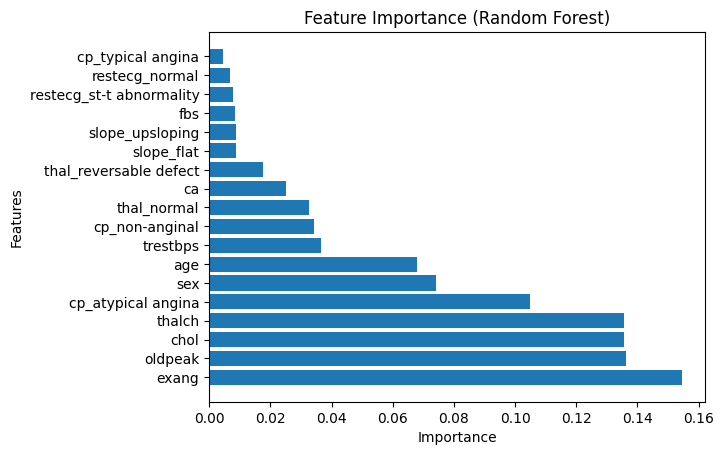

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [23]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(rf2, threshold=0.02)

X_selected = selector.fit_transform(X, Y)

selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['age', 'sex', 'trestbps', 'chol', 'thalch', 'exang', 'oldpeak', 'ca',
       'cp_atypical angina', 'cp_non-anginal', 'thal_normal'],
      dtype='object')
